In [40]:
import pandas as pd

df = pd.read_csv("/Users/harshityadav/Documents/Python/1-Pythonbasics/Zomato_DA/data/zomato.csv",encoding="latin1")  # use your kaggle file
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [41]:
df.shape

(9551, 21)

In [42]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='str')

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   str    
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   str    
 4   Address               9551 non-null   str    
 5   Locality              9551 non-null   str    
 6   Locality Verbose      9551 non-null   str    
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   str    
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   str    
 12  Has Table booking     9551 non-null   str    
 13  Has Online delivery   9551 non-null   str    
 14  Is delivering now     9551 non-null   str    
 15  Switch to order menu  9551 non-n

In [44]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [45]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [46]:
df["Cuisines"]=df["Cuisines"].fillna("Unknown")

In [47]:
df = df.rename(columns={
    "Aggregate rating": "rating",
    "Average Cost for two": "cost",
    "Votes": "votes"
})

In [48]:
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["votes"] = pd.to_numeric(df["votes"], errors="coerce")
df["cost"] = pd.to_numeric(df["cost"], errors="coerce")

In [49]:
df = df[df["rating"] > 0]

In [50]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,cost,Price range,rating,votes
count,7.403000e+03,7403.000000,7403.000000,7403.000000,7403.000000,7403.000000,7403.000000,7403.000000
mean,7.158676e+06,23.268675,63.462859,26.182970,1448.415102,1.970147,3.440024,202.185060
std,8.444634e+06,63.426253,44.696549,11.267380,18303.524265,0.930611,0.552195,479.195199
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,1.800000,4.000000
25%,1.534450e+04,1.000000,77.082416,28.475505,300.000000,1.000000,3.000000,19.000000
50%,3.120540e+05,1.000000,77.191784,28.570000,500.000000,2.000000,3.400000,60.000000
75%,1.821955e+07,1.000000,77.272293,28.645259,800.000000,3.000000,3.800000,181.000000
max,1.849606e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [51]:
upper_limit = df["cost"].quantile(0.99)
df = df[df["cost"] <= upper_limit]

In [52]:
df.shape
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,cost,Price range,rating,votes
count,7.340000e+03,7340.000000,7340.000000,7340.000000,7340.000000,7340.000000,7340.000000,7340.000000
mean,7.172530e+06,23.145913,63.268327,26.266044,627.386512,1.955722,3.435245,199.877248
std,8.453482e+06,63.513257,44.807348,11.179020,562.835536,0.920213,0.550672,477.893065
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,1.800000,4.000000
25%,2.086300e+04,1.000000,77.081943,28.475743,300.000000,1.000000,3.000000,18.000000
50%,3.120855e+05,1.000000,77.191202,28.569998,500.000000,2.000000,3.400000,59.000000
75%,1.821955e+07,1.000000,77.270559,28.645560,800.000000,3.000000,3.800000,178.000000
max,1.849606e+07,216.000000,174.832089,55.976980,4000.000000,4.000000,4.900000,10934.000000


In [53]:
df["Country Code"].value_counts()

Country Code
1      6473
216     431
215      79
214      60
189      60
30       55
148      40
208      34
14       24
162      21
184      20
166      20
191      19
37        4
Name: count, dtype: int64

In [54]:
df["Country Code"].value_counts(normalize=True) * 100

Country Code
1      88.188011
216     5.871935
215     1.076294
214     0.817439
189     0.817439
30      0.749319
148     0.544959
208     0.463215
14      0.326975
162     0.286104
184     0.272480
166     0.272480
191     0.258856
37      0.054496
Name: proportion, dtype: float64

In [55]:
df=df[df["Country Code"]==1]

In [56]:
df["Country Code"].value_counts(normalize=True) * 100

Country Code
1    100.0
Name: proportion, dtype: float64

In [57]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,cost,Price range,rating,votes
count,6.473000e+03,6473.0,6473.000000,6473.000000,6473.000000,6473.000000,6473.000000,6473.000000
mean,6.405506e+06,1.0,74.785195,26.944828,689.111695,1.869612,3.349158,181.162367
std,8.465487e+06,0.0,13.838223,5.724321,548.057841,0.871180,0.504271,485.115320
min,5.300000e+01,1.0,0.000000,0.000000,0.000000,1.000000,1.800000,4.000000
25%,8.801000e+03,1.0,77.102278,28.489834,350.000000,1.000000,3.000000,16.000000
50%,3.095310e+05,1.0,77.204192,28.569040,500.000000,2.000000,3.300000,49.000000
75%,1.824699e+07,1.0,77.281826,28.639065,800.000000,2.000000,3.700000,147.000000
max,1.849211e+07,1.0,91.806493,31.655589,4000.000000,4.000000,4.900000,10934.000000


In [58]:
df["Price range"].value_counts()

Price range
1    2596
2    2462
3    1078
4     337
Name: count, dtype: int64

In [59]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,rating,Rating color,Rating text,votes
624,3400025,Jahanpanah,1,Agra,"E 23, Shopping Arcade, Sadar Bazaar, Agra Cant...",Agra Cantt,"Agra Cantt, Agra",78.011544,27.161661,"North Indian, Mughlai",...,Indian Rupees(Rs.),No,No,No,No,3,3.9,Yellow,Good,140
625,3400341,Rangrezz Restaurant,1,Agra,"E-20, Shopping Arcade, Sadar Bazaar, Agra Cant...",Agra Cantt,"Agra Cantt, Agra",0.000000,0.000000,"North Indian, Mughlai",...,Indian Rupees(Rs.),No,No,No,No,2,3.5,Yellow,Good,71
626,3400005,Time2Eat - Mama Chicken,1,Agra,"Main Market, Sadar Bazaar, Agra Cantt, Agra",Agra Cantt,"Agra Cantt, Agra",78.011608,27.160832,North Indian,...,Indian Rupees(Rs.),No,No,No,No,2,3.6,Yellow,Good,94
627,3400021,Chokho Jeeman Marwari Jain Bhojanalya,1,Agra,"1/48, Delhi Gate, Station Road, Raja Mandi, Ci...",Civil Lines,"Civil Lines, Agra",77.998092,27.195928,Rajasthani,...,Indian Rupees(Rs.),No,No,No,No,2,4.0,Green,Very Good,87
628,3400017,Pinch Of Spice,1,Agra,"23/453, Opposite Sanjay Cinema, Wazipura Road,...",Civil Lines,"Civil Lines, Agra",78.007553,27.201725,"North Indian, Chinese, Mughlai",...,Indian Rupees(Rs.),No,No,No,No,3,4.2,Green,Very Good,177


In [60]:
df = df.drop(columns=[
    "Restaurant ID",
    "Address",
    "Locality Verbose",
    "Longitude",
    "Latitude",
    "Currency",
    "Rating color",
    "Rating text"
])

In [61]:
df=df.drop(columns=["Switch to order menu"])

In [62]:
df=df.drop(columns=["Is delivering now"])

In [63]:
df.head(10)

,Restaurant Name,Country Code,City,Locality,Cuisines,cost,Has Table booking,Has Online delivery,Price range,rating,votes
624,Jahanpanah,1,Agra,Agra Cantt,"North Indian, Mughlai",850,No,No,3,3.9,140
625,Rangrezz Restaurant,1,Agra,Agra Cantt,"North Indian, Mughlai",700,No,No,2,3.5,71
626,Time2Eat - Mama Chicken,1,Agra,Agra Cantt,North Indian,500,No,No,2,3.6,94
627,Chokho Jeeman Marwari Jain Bhojanalya,1,Agra,Civil Lines,Rajasthani,400,No,No,2,4.0,87
628,Pinch Of Spice,1,Agra,Civil Lines,"North Indian, Chinese, Mughlai",1000,No,No,3,4.2,177
629,MoMo Cafe,1,Agra,"Courtyard by Marriott Agra, Tajganj","North Indian, European",2000,No,No,4,4.0,45
630,Peshawri - ITC Mughal,1,Agra,"ITC Mughal, Tajganj","North Indian, Mughlai",2500,No,No,4,4.3,133
631,Taj Bano - ITC Mughal,1,Agra,"ITC Mughal, Tajganj",Mughlai,2500,No,No,4,4.0,41
632,G Thal,1,Agra,Khandari,"Rajasthani, Gujarati, Mughlai",800,No,No,3,3.6,59
633,Dawat-e-Nawab - Radisson Blu,1,Agra,"Radisson Blu, Tajganj","North Indian, Mughlai",3600,No,No,4,3.8,46


In [64]:
df = df[df["Cuisines"] != "Unknown"]

In [65]:
df.isnull().sum()

Restaurant Name        0
Country Code           0
City                   0
Locality               0
Cuisines               0
cost                   0
Has Table booking      0
Has Online delivery    0
Price range            0
rating                 0
votes                  0
dtype: int64

In [66]:
df.head()

,Restaurant Name,Country Code,City,Locality,Cuisines,cost,Has Table booking,Has Online delivery,Price range,rating,votes
624,Jahanpanah,1,Agra,Agra Cantt,"North Indian, Mughlai",850,No,No,3,3.9,140
625,Rangrezz Restaurant,1,Agra,Agra Cantt,"North Indian, Mughlai",700,No,No,2,3.5,71
626,Time2Eat - Mama Chicken,1,Agra,Agra Cantt,North Indian,500,No,No,2,3.6,94
627,Chokho Jeeman Marwari Jain Bhojanalya,1,Agra,Civil Lines,Rajasthani,400,No,No,2,4.0,87
628,Pinch Of Spice,1,Agra,Civil Lines,"North Indian, Chinese, Mughlai",1000,No,No,3,4.2,177


In [67]:
df["Cuisines"].value_counts().head(100)

Cuisines
North Indian                        490
North Indian, Chinese               397
North Indian, Mughlai               294
Cafe                                232
Fast Food                           222
                                   ... 
Chinese, Mughlai, North Indian        8
North Indian, Fast Food, Chinese      8
Italian, Pizza, Bakery                8
South Indian, Fast Food               8
Italian, Fast Food                    7
Name: count, Length: 100, dtype: int64

In [68]:
df["Cuisines"] = df["Cuisines"].str.split(", ")
df_exploded = df.explode("Cuisines")
df_exploded["Cuisines"].value_counts().head(10)

Cuisines
North Indian    2994
Chinese         2128
Fast Food       1540
Mughlai          790
Continental      677
Italian          633
Cafe             559
Bakery           517
Desserts         487
South Indian     478
Name: count, dtype: int64

In [69]:
df_exploded.groupby("Cuisines")["rating"].mean().sort_values(ascending=False).head(10)

Cuisines
Persian           4.600000
German            4.350000
Modern Indian     4.240000
Charcoal Grill    4.175000
Parsi             4.100000
Iranian           4.066667
Burmese           4.050000
Steak             4.050000
Indonesian        4.000000
Mediterranean     3.987356
Name: rating, dtype: float64

In [70]:
df_exploded.groupby("Cuisines")["votes"].mean().sort_values(ascending=False).head(10)

Cuisines
Iranian          1791.333333
German           1132.000000
African          1024.750000
Tex-Mex           957.187500
Modern Indian     944.866667
Spanish           930.666667
Mediterranean     830.827586
Portuguese        824.400000
European          799.642857
Parsi             799.250000
Name: votes, dtype: float64

In [71]:
df.shape

(6473, 11)

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.figure(figsize=(15,10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

/var/folders/r1/1f68lyg163q7dxc8ts17hs3h0000gn/T/ipykernel_18270/4061069418.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cuisines.values,y=top_cuisines.index,palette="viridis")


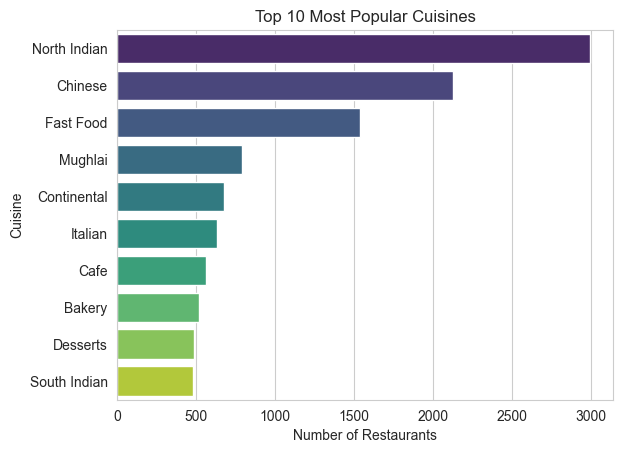

In [73]:
top_cuisines=df_exploded["Cuisines"].value_counts().head(10)
sns.barplot(x=top_cuisines.values,y=top_cuisines.index,palette="viridis")
plt.title("Top 10 Most Popular Cuisines")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")
plt.show()

In [74]:
cuisines_counts=df_exploded["Cuisines"].value_counts(normalize=True)*100
cuisines_counts.cumsum().head(10)

Cuisines
North Indian    20.868474
Chinese         35.700843
Fast Food       46.434795
Mughlai         51.941172
Continental     56.659929
Italian         61.072001
Cafe            64.968286
Bakery          68.571827
Desserts        71.966265
South Indian    75.297972
Name: proportion, dtype: float64

In [75]:
df_exploded.groupby("Cuisines")["rating"].mean().sort_values(ascending=False).head(10)

Cuisines
Persian           4.600000
German            4.350000
Modern Indian     4.240000
Charcoal Grill    4.175000
Parsi             4.100000
Iranian           4.066667
Burmese           4.050000
Steak             4.050000
Indonesian        4.000000
Mediterranean     3.987356
Name: rating, dtype: float64

In [76]:
cuisines_stats=df_exploded.groupby("Cuisines").agg({
    "rating":"mean",
    "votes":"count"
})
cuisines_stats.columns=["rating","restaurant_count"]
avg_count=cuisines_stats["restaurant_count"].mean()
cuisines_stats=cuisines_stats[cuisines_stats["restaurant_count"]>avg_count]
cuisines_stats.sort_values(by="restaurant_count",ascending=False)

,rating,restaurant_count
Cuisines,,
North Indian,3.289880,2994
Chinese,3.265508,2128
Fast Food,3.250065,1540
Mughlai,3.266709,790
Continental,3.697489,677
Italian,3.705371,633
Cafe,3.625224,559
Bakery,3.366151,517
Desserts,3.504517,487


In [85]:
df.to_excel("cleaned_final1.xlsx", index=False)

In [81]:
df["Cuisines"] = df["Cuisines"].apply(lambda x: ", ".join(x) if isinstance(x, list) else x)

In [82]:
df.head()

,Restaurant Name,Country Code,City,Locality,Cuisines,cost,Has Table booking,Has Online delivery,Price range,rating,votes
624,Jahanpanah,1,Agra,Agra Cantt,"North Indian, Mughlai",850,No,No,3,3.9,140
625,Rangrezz Restaurant,1,Agra,Agra Cantt,"North Indian, Mughlai",700,No,No,2,3.5,71
626,Time2Eat - Mama Chicken,1,Agra,Agra Cantt,North Indian,500,No,No,2,3.6,94
627,Chokho Jeeman Marwari Jain Bhojanalya,1,Agra,Civil Lines,Rajasthani,400,No,No,2,4.0,87
628,Pinch Of Spice,1,Agra,Civil Lines,"North Indian, Chinese, Mughlai",1000,No,No,3,4.2,177


In [83]:
df.to_csv("cleaned_final.csv", index=False)